<a href="https://colab.research.google.com/github/HarryYardley/Talias-Job-Scraper/blob/main/Talia's_Jobs_Web_Scraper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import sqlite3
import time
import random
from datetime import datetime, timedelta
import re
from google.colab import files
import io
import os
from tqdm.notebook import tqdm
import urllib.parse

In [2]:
JOB_TITLES = ["Mechanical Engineer", "Product Engineer", "Manufacturing Engineer", "Process Engineer"]

EXPERIENCE_KEYWORDS = ["entry level", "new grad", "junior", "0-1 year", "0-1 years", "entry-level",
                       "associate", "graduate", "recent graduate", "early career"]

# Location priorities, 1st and 2nd
PRIORITY_1_LOCATIONS = ["New York", "Pennsylvania", "Vermont", "Massachusetts"]
PRIORITY_2_LOCATIONS = ["Maine", "New Hampshire", "Rhode Island", "Connecticut", "New Jersey",
                       "Delaware", "Maryland", "Virginia", "North Carolina", "South Carolina",
                       "Georgia", "Florida", "Ohio", "Michigan", "Indiana", "Illinois",
                       "Wisconsin", "Minnesota", "Iowa", "Missouri", "North Dakota",
                       "South Dakota", "Nebraska", "Kansas", "Colorado"]

PRIORITY_1_INDUSTRIES = ["toys", "games", "outdoor", "sportswear", "sports equipment", "playground",
                        "board game", "puzzle", "collectible", "STEM toy", "educational toy"]
PRIORITY_2_INDUSTRIES = ["automotive", "food", "beverage", "packaging", "consumer appliances",
                        "appliances", "footwear", "apparel", "gear", "recreation"]

TOYS_GAMES_COMPANIES = [
    # Major Toy Manufacturers
    "Mattel", "Hasbro", "LEGO", "Spin Master", "Bandai", "Namco", "Bandai Namco",
    "Playmates", "Jakks Pacific", "Jakks", "Tomy", "Moose Toys", "Funko",

    # Board Game and Puzzle Companies
    "Ravensburger", "Asmodee", "Days of Wonder", "Fantasy Flight", "Wizards of the Coast",
    "Steve Jackson Games", "Z-Man Games", "Rio Grande Games", "Mayfair Games", "ThinkFun",

    # Playground Equipment Manufacturers
    "PlayCore", "Landscape Structures", "Kompan", "Playworld", "Little Tikes",
    "Miracle Recreation", "GameTime", "Burke Playgrounds", "ECR4Kids", "Superior Recreational",

    # Educational and STEM Toy Companies
    "Learning Resources", "Melissa & Doug", "VTech", "LeapFrog", "Fisher-Price",
    "Discovery Toys", "SmartLab", "Thames & Kosmos", "Educational Insights", "K'NEX",

    # Specialty and Collectible Toy Companies
    "NECA", "National Entertainment Collectibles", "McFarlane Toys", "McFarlane",
    "Mezco Toyz", "Mezco", "Diamond Select", "Sideshow", "Kidrobot",
    "Super7", "Bif Bang Pow", "The Loyal Subjects", "Beast Kingdom"
]

# Priority 1 companies - Outdoor and Sportswear
OUTDOOR_COMPANIES = [
    # Major Outdoor Apparel and Gear Brands
    "Patagonia", "North Face", "Columbia Sportswear", "Columbia", "REI", "Arc'teryx",
    "Arcteryx", "Marmot", "Mountain Hardwear", "Outdoor Research", "Black Diamond", "Fjällräven",

    # Footwear Brands
    "Merrell", "Salomon", "Keen", "Danner", "Vasque", "La Sportiva", "Oboz",
    "Hoka One One", "Hoka", "Altra Running", "Altra", "Scarpa",

    # Specialty and Emerging Brands
    "Cotopaxi", "Prana", "Kühl", "Kuhl", "Filson", "Helly Hansen", "Rab",
    "Montbell", "Duckworth", "Western Mountaineering", "NEMO Equipment", "NEMO"
]

# Priority 2 companies - Automotive
AUTOMOTIVE_COMPANIES = [
    "General Motors", "GM", "Chevrolet", "Chevy", "GMC", "Cadillac", "Buick",
    "Ford", "Lincoln", "Stellantis", "Chrysler", "Dodge", "Jeep", "Ram",
    "Tesla", "Toyota", "Honda", "Nissan", "Hyundai"
]

# Combine all companies into priority lists
PRIORITY_1_COMPANIES = TOYS_GAMES_COMPANIES + OUTDOOR_COMPANIES
PRIORITY_2_COMPANIES = AUTOMOTIVE_COMPANIES

In [3]:
import re

STOPWORDS = {"the", "and", "inc", "llc", "ltd", "corp", "corporation", "co", "of", "for", "a"}

def tokenize(name):
    """
    Tokenize the input name into a set of words.
    Only include words that are at least 3 characters long and are not in STOPWORDS.
    """
    tokens = re.findall(r'\w+', name.lower())
    tokens = {token for token in tokens if len(token) >= 3 and token not in STOPWORDS}
    return tokens

def company_name_match(company_name, priority_companies):
    """
    Check if a company name matches any in the priority list by comparing normalized tokens.
    This function will only return True if there is an exact token match (ignoring common words),
    reducing false positives from loose substring matching.
    """
    company_tokens = tokenize(company_name)
    for pc in priority_companies:
        pc_tokens = tokenize(pc)
        if company_tokens & pc_tokens:
            return True
    return False

def calculate_priority_score(job_title, company, location, description):
    score = 0

    if any(loc.lower() in location.lower() for loc in PRIORITY_1_LOCATIONS):
        score += 30
    elif any(loc.lower() in location.lower() for loc in PRIORITY_2_LOCATIONS):
        score += 15

    if company_name_match(company, PRIORITY_1_COMPANIES):
        score += 30
    elif company_name_match(company, PRIORITY_2_COMPANIES):
        score += 15

    description_lower = description.lower()
    if any(keyword in description_lower for keyword in PRIORITY_1_INDUSTRIES):
        score += 20
    elif any(keyword in description_lower for keyword in PRIORITY_2_INDUSTRIES):
        score += 10

    if any(keyword in job_title.lower() or keyword in description_lower for keyword in EXPERIENCE_KEYWORDS):
        score += 15

    job_date = get_job_date(description)
    if job_date and is_within_last_month(job_date):
        score += 10
    elif job_date and is_within_last_two_months(job_date):
        score += 5

    return score

def get_job_date(description):
    """
    Extract job posting date from description.
    This is a placeholder - implement based on your data structure.
    """
    return None

def is_within_last_month(date):
    """
    Check if a date is within the last month.
    """
    if not date:
        return False
    today = datetime.now()
    one_month_ago = today - timedelta(days=30)
    return date >= one_month_ago

def is_within_last_two_months(date):
    """
    Check if a date is within the last two months.
    """
    if not date:
        return False
    today = datetime.now()
    two_months_ago = today - timedelta(days=60)
    return date >= two_months_ago

def scrape_linkedin_simple(conn):
    print("Scraping jobs from LinkedIn's job search API...")
    cursor = conn.cursor()

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    total_jobs = 0
    job_progress = tqdm(total=len(JOB_TITLES) * len(PRIORITY_1_LOCATIONS + PRIORITY_2_LOCATIONS),
                        desc="LinkedIn Progress", leave=False)

    for job_title in JOB_TITLES:
        for location in PRIORITY_1_LOCATIONS + PRIORITY_2_LOCATIONS:
            formatted_title = urllib.parse.quote_plus(job_title)
            formatted_location = urllib.parse.quote_plus(location)

            search_url = f"https://www.linkedin.com/jobs-guest/jobs/api/seeMoreJobPostings/search?keywords={formatted_title}&location={formatted_location}&f_TPR=r5184000&start=0"

            try:
                response = requests.get(search_url, headers=headers)
                soup = BeautifulSoup(response.text, 'html.parser')

                job_cards = soup.select('li')

                for card in job_cards:
                    try:
                        title_element = card.select_one('h3.base-search-card__title')
                        company_element = card.select_one('h4.base-search-card__subtitle')
                        location_element = card.select_one('span.job-search-card__location')
                        link_element = card.select_one('a.base-card__full-link')
                        date_element = card.select_one('time.job-search-card__listdate')

                        if title_element and company_element and location_element and link_element:
                            title = title_element.text.strip()
                            company = company_element.text.strip()
                            job_location = location_element.text.strip()
                            url = link_element.get('href')
                            date_posted = date_element.get('datetime') if date_element else None

                            # Get a brief description
                            description = f"Job Title: {title}\nCompany: {company}\nLocation: {job_location}\n"
                            if date_posted:
                                description += f"Posted: {date_posted}\n"
                            description += "This is a simplified entry. Click the link for full details."

                            priority_score = calculate_priority_score(title, company, job_location, description)

                            cursor.execute('''
                            INSERT OR IGNORE INTO jobs (job_title, company, location, description, url, date_posted, date_scraped, job_site, priority_score)
                            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
                            ''', (title, company, job_location, description, url,
                                  date_posted, datetime.now().strftime("%Y-%m-%d %H:%M:%S"), "LinkedIn", priority_score))
                            conn.commit()
                            total_jobs += 1

                    except Exception as e:
                        print(f"Error processing LinkedIn job: {str(e)}")

                time.sleep(random.uniform(1, 2))

            except Exception as e:
                print(f"Error scraping LinkedIn page: {str(e)}")

            job_progress.update(1)

    job_progress.close()
    print(f"Scraped {total_jobs} jobs from LinkedIn")

In [4]:
def init_db():
    conn = sqlite3.connect(':memory:')
    cursor = conn.cursor()
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS jobs (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        job_title TEXT,
        company TEXT,
        location TEXT,
        description TEXT,
        url TEXT UNIQUE,
        date_posted TEXT,
        date_scraped TEXT,
        job_site TEXT,
        priority_score INTEGER
    )
    ''')
    conn.commit()
    return conn

def get_company_industry(company):
    """
    Determine which industry a company belongs to based on our company lists.

    Args:
        company: Company name as string

    Returns:
        String with industry category: "Toys & Games", "Outdoor & Sportswear", "Automotive", or "Other"
    """
    company_lower = company.lower()

    if company_name_match(company, TOYS_GAMES_COMPANIES):
        return "Toys & Games"
    elif company_name_match(company, OUTDOOR_COMPANIES):
        return "Outdoor & Sportswear"
    elif company_name_match(company, AUTOMOTIVE_COMPANIES):
        return "Automotive"

    return "Other"

def display_results(conn):
    query = '''
    SELECT job_title, company, location, description, url, job_site, priority_score, date_posted
    FROM jobs
    ORDER BY priority_score DESC
    '''

    df = pd.read_sql_query(query, conn)

    df['industry'] = df['company'].apply(get_company_industry)

    def highlight_priority(s):
        score = s['priority_score']

        if score >= 50:
            return ['background-color: #d4f7d4'] * len(s)  # High priority - light green
        elif score >= 30:
            return ['background-color: #fff2cc'] * len(s)  # Medium priority - light yellow
        else:
            return ['background-color: #f7f7f7'] * len(s)  # Low priority - light gray

    def highlight_industry(val):
        if val == "Toys & Games":
            return 'background-color: #d0e0ff'  # Light blue
        elif val == "Outdoor & Sportswear":
            return 'background-color: #d8f8d8'  # Light green
        elif val == "Automotive":
            return 'background-color: #ffe0e0'  # Light red
        else:
            return ''

    pd.set_option('display.max_colwidth', None)
    df['url'] = df['url'].apply(lambda x: f'<a href="{x}" target="_blank">View Job</a>')
    df['priority'] = df['priority_score'].apply(lambda x:
                                             'High' if x >= 50 else
                                             'Medium' if x >= 30 else
                                             'Low')

    def categorize_location(loc):
        if any(pl.lower() in loc.lower() for pl in PRIORITY_1_LOCATIONS):
            return 'Priority 1'
        elif any(pl.lower() in loc.lower() for pl in PRIORITY_2_LOCATIONS):
            return 'Priority 2'
        else:
            return 'Other'

    df['location_priority'] = df['location'].apply(categorize_location)

    def get_posting_age(date_str):
        if not date_str:
            return "Unknown"

        try:
            if 'T' in date_str:  # ISO format from LinkedIn
                date_posted = datetime.fromisoformat(date_str.split('T')[0])
            elif 'ago' in date_str:
                days_ago = int(re.search(r'(\d+)', date_str).group(1))
                date_posted = datetime.now() - timedelta(days=days_ago)
            else:
                date_posted = datetime.strptime(date_str, "%Y-%m-%d")
        except:
            return "Unknown"

        days_old = (datetime.now() - date_posted).days

        if days_old < 7:
            return f"{days_old}d (New!)"
        elif days_old < 30:
            return f"{days_old}d"
        else:
            return f"{days_old}d (Older)"

    if 'date_posted' in df.columns:
        df['age'] = df['date_posted'].apply(get_posting_age)

    print(f"Total jobs found: {len(df)}")
    print(f"High priority jobs: {len(df[df['priority'] == 'High'])}")
    print(f"Priority 1 locations: {len(df[df['location_priority'] == 'Priority 1'])}")

    industry_counts = df['industry'].value_counts()
    print("\nIndustry breakdown:")
    for industry, count in industry_counts.items():
        print(f"  {industry}: {count} jobs")
    print("\n")

    display_cols = ['job_title', 'company', 'industry', 'location', 'priority', 'priority_score']

    if 'age' in df.columns:
        display_cols.append('age')

    display_cols.extend(['job_site', 'url'])

    styled_df = df[display_cols].head(20)

    styled_df = styled_df.style.apply(highlight_priority, axis=1)\
                              .applymap(highlight_industry, subset=['industry'])

    display(styled_df)

    df.to_csv('job_results.csv', index=False)

    from google.colab import files
    files.download('job_results.csv')

    return df

def create_filtered_views(df):
    display_cols = ['job_title', 'company', 'industry', 'location', 'priority_score', 'url']

    if 'age' in df.columns:
        display_cols.append('age')

    priority_1_loc = df[df['location_priority'] == 'Priority 1']

    toys_games = df[df['industry'] == 'Toys & Games']
    outdoor = df[df['industry'] == 'Outdoor & Sportswear']
    auto = df[df['industry'] == 'Automotive']

    mechanical = df[df['job_title'].str.contains('Mechanical', case=False)]
    product = df[df['job_title'].str.contains('Product', case=False)]
    manufacturing = df[df['job_title'].str.contains('Manufacturing', case=False)]

    print("\n--- Top Priority 1 Location Jobs ---")
    display(priority_1_loc.head(10)[display_cols])

    print("\n--- Top Toys & Games Industry Jobs ---")
    display(toys_games.head(10)[display_cols])

    print("\n--- Top Outdoor & Sportswear Industry Jobs ---")
    display(outdoor.head(10)[display_cols])

    print("\n--- Top Automotive Industry Jobs ---")
    display(auto.head(10)[display_cols])

    print("\n--- Mechanical Engineering Jobs ---")
    display(mechanical.head(10)[display_cols])

    print("\n--- Product Engineering Jobs ---")
    display(product.head(10)[display_cols])

    print("\n--- Manufacturing Engineering Jobs ---")
    display(manufacturing.head(10)[display_cols])

In [5]:
def run_job_scraper():
    print("🔍 Starting job alert scraper...\n")
    print("⚙️ This version is optimized for Google Colab and refreshes on each run.\n")

    print("🎯 Target Job Titles:")
    for title in JOB_TITLES:
        print(f"  - {title}")

    print("\n🌎 Priority 1 Locations:")
    for loc in PRIORITY_1_LOCATIONS:
        print(f"  - {loc}")

    print("\n🏢 Priority 1 Companies/Industries:")
    companies_display = PRIORITY_1_COMPANIES[:5]
    print(f"  - {', '.join(companies_display)} and {len(PRIORITY_1_COMPANIES) - 5} more")

    conn = init_db()

    try:
        scrape_linkedin_simple(conn)
    except Exception as e:
        print(f"LinkedIn scraper error: {str(e)}")

    print("\n📊 Results:")
    df = display_results(conn)
    create_filtered_views(df)

    print("\n✅ Job scraping complete! Results are displayed above and have been exported to job_results.csv.")
    conn.close()

🔍 Starting job alert scraper...

⚙️ This version is optimized for Google Colab and refreshes on each run.

🎯 Target Job Titles:
  - Mechanical Engineer
  - Product Engineer
  - Manufacturing Engineer
  - Process Engineer

🌎 Priority 1 Locations:
  - New York
  - Pennsylvania
  - Vermont
  - Massachusetts

🏢 Priority 1 Companies/Industries:
  - Mattel, Hasbro, LEGO, Spin Master, Bandai and 87 more
Scraping jobs from LinkedIn's job search API...


LinkedIn Progress:   0%|          | 0/116 [00:00<?, ?it/s]

Scraped 1159 jobs from LinkedIn

📊 Results:
Total jobs found: 1159
High priority jobs: 0
Priority 1 locations: 20

Industry breakdown:
  Other: 1100 jobs
  Automotive: 33 jobs
  Outdoor & Sportswear: 18 jobs
  Toys & Games: 8 jobs




<ipython-input-4-f7b1d00aa9e1>:165: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_industry, subset=['industry'])


,job_title,company,industry,location,priority,priority_score,age,job_site,url
0,Mechanical Engineer,Vallum Associates,Other,"New York, NY",Medium,45,26d,LinkedIn,View Job
1,Transformational Business Process Engineering Consultant - Associate,BBVA,Other,"New York, NY",Medium,45,14d,LinkedIn,View Job
2,Product Design Engineer - NTI,Meta,Other,"New York, NY",Medium,30,16d,LinkedIn,View Job
3,"Product Design Engineer, Reality Labs",Oculus VR,Other,"New York, NY",Medium,30,16d,LinkedIn,View Job
4,Design Engineer,Helen of Troy,Other,"New York, NY",Medium,30,3d (New!),LinkedIn,View Job
5,Continuous Improvement Engineer,"Legrand, North America",Outdoor & Sportswear,"Canonsburg, PA",Medium,30,16d,LinkedIn,View Job
6,Manufacturing Engineer,Weidmann Electrical Technology,Other,"Vermont, United States",Medium,30,27d,LinkedIn,View Job
7,Manufacturing Engineer - Mid-Level,DEKA Research & Development,Outdoor & Sportswear,"Manchester, NH",Medium,30,7d,LinkedIn,View Job
8,Senior Manufacturing Engineer,DEKA Research & Development,Outdoor & Sportswear,"Manchester, NH",Medium,30,7d,LinkedIn,View Job
9,Design Quality Engineer,JBL Resources,Toys & Games,"Wilmington, DE",Medium,30,9d,LinkedIn,View Job


...

,job_title,company,industry,location,priority_score,url,age
0,Mechanical Engineer,Vallum Associates,Other,"New York, NY",45,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-at-vallum-associates-4201304715?position=2&pageNum=0&refId=5%2FsZQl9louHX3CYwdsqKMQ%3D%3D&trackingId=PHlXjFgmEtdtHP0QI%2BZ04Q%3D%3D"" target=""_blank"">View Job</a>",26d
10,Mechanical Engineer,Advanced Technology and Research Corporation,Outdoor & Sportswear,"Bethesda, MD",30,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-at-advanced-technology-and-research-corporation-4211048543?position=9&pageNum=0&refId=%2FqEtPPJ9lc9i966SmwMELg%3D%3D&trackingId=GVtuq3MGONbY6kjFIdNIOA%3D%3D"" target=""_blank"">View Job</a>",15d
11,Mechanical Engineer,Aurora Flight Sciences,Toys & Games,"Manassas, VA",30,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-at-aurora-flight-sciences-4208433221?position=4&pageNum=0&refId=URWwwsAG0otQ%2FzttGr8Y%2Bw%3D%3D&trackingId=du7euuZWMDflPg%2Ff2M9QdA%3D%3D"" target=""_blank"">View Job</a>",16d
14,Mechanical Engineer,Toyota North America,Outdoor & Sportswear,"Princeton, IN",30,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-at-toyota-north-america-4210660332?position=2&pageNum=0&refId=hsJWpAwoW%2BxuKb48J%2Bk%2B%2FA%3D%3D&trackingId=Cye%2BiYsfuM1pbCR%2FZDZAVA%3D%3D"" target=""_blank"">View Job</a>",15d
26,Mechanical Engineer (Product),"Legrand, North America",Outdoor & Sportswear,"Concord, NC",30,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-product-at-legrand-north-america-4198188329?position=10&pageNum=0&refId=XhtlLDC1etMlPw%2FIzogpHA%3D%3D&trackingId=cYxrhfjf3ebLj%2FpPDaXMdA%3D%3D"" target=""_blank"">View Job</a>",27d
27,Mechanical Design Engineer,Rittal North America LLC,Outdoor & Sportswear,"Urbana, OH",30,"<a href=""https://www.linkedin.com/jobs/view/mechanical-design-engineer-at-rittal-north-america-llc-4189542734?position=6&pageNum=0&refId=mBxJ4PaBiR%2F3x2m9gikwpg%3D%3D&trackingId=ZmIQSBQk2WCbMPNuArQpjw%3D%3D"" target=""_blank"">View Job</a>",8d
30,Senior Mechanical Engineer,Brightpath Associates LLC,Other,"Nebraska, United States",30,"<a href=""https://www.linkedin.com/jobs/view/senior-mechanical-engineer-at-brightpath-associates-llc-4219187241?position=6&pageNum=0&refId=pP1IjyinDZ8bpuKUhhspsQ%3D%3D&trackingId=k%2FV%2BDQFZts4SZxrRqVuhpQ%3D%3D"" target=""_blank"">View Job</a>",1d (New!)
42,Senior Mechanical Engineer,Brightpath Associates LLC,Other,"Nebraska, United States",30,"<a href=""https://www.linkedin.com/jobs/view/senior-mechanical-engineer-at-brightpath-associates-llc-4219187241?position=7&pageNum=0&refId=I49qUQPQJci1gLLzw2rnYw%3D%3D&trackingId=hE39kgk9%2FN1pu2mxAUvYMg%3D%3D"" target=""_blank"">View Job</a>",1d (New!)
50,Mechanical Engineer - Consumer Products Packaging (Multiple Locations),Burns & McDonnell,Other,"Kansas City, MO",25,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-consumer-products-packaging-multiple-locations-at-burns-mcdonnell-4188558802?position=6&pageNum=0&refId=kzmrpnJS1DPBK2X5gHcBQw%3D%3D&trackingId=J3IRkN2YwA%2FnfsA9%2Bn%2B6%2Bw%3D%3D"" target=""_blank"">View Job</a>",15d
51,Mechanical Engineer - Consumer Products Packaging (Multiple Locations),Burns & McDonnell,Other,"Kansas City, MO",25,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-consumer-products-packaging-multiple-locations-at-burns-mcdonnell-4188558802?position=7&pageNum=0&refId=ZiF8QhTThPP0r9uaZTnTEg%3D%3D&trackingId=8oJ%2BOCL%2B9cD%2FfjEEDYWXpg%3D%3D"" target=""_blank"">View Job</a>",15d



--- Product Engineering Jobs ---


,job_title,company,industry,location,priority_score,url,age
2,Product Design Engineer - NTI,Meta,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/product-design-engineer-nti-at-meta-4206342599?position=1&pageNum=0&refId=5%2FsZQl9louHX3CYwdsqKMQ%3D%3D&trackingId=bZFt%2BK96JAuJCXoRSDtQ7w%3D%3D"" target=""_blank"">View Job</a>",16d
3,"Product Design Engineer, Reality Labs",Oculus VR,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/product-design-engineer-reality-labs-at-oculus-vr-4151158397?position=3&pageNum=0&refId=5%2FsZQl9louHX3CYwdsqKMQ%3D%3D&trackingId=65J4BGRWBmjzRVXpGPauGQ%3D%3D"" target=""_blank"">View Job</a>",16d
13,Manufacturing Engineer - New Product Introduction,Rittal North America LLC,Outdoor & Sportswear,"Urbana, OH",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-new-product-introduction-at-rittal-north-america-llc-4008040623?position=5&pageNum=0&refId=9fAHFzkX9qd1htn5bVjzsA%3D%3D&trackingId=mBtnbkX7FUyHKVtb41ieeQ%3D%3D"" target=""_blank"">View Job</a>",8d
15,Product Design Engineer - NTI,Meta,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/product-design-engineer-nti-at-meta-4206342599?position=1&pageNum=0&refId=uT7SaGHTJTNdQ34cH9Tx0A%3D%3D&trackingId=xAaz30KilC8AKN64jsPjTQ%3D%3D"" target=""_blank"">View Job</a>",16d
16,"Product Design Engineer, Reality Labs",Oculus VR,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/product-design-engineer-reality-labs-at-oculus-vr-4151158397?position=2&pageNum=0&refId=uT7SaGHTJTNdQ34cH9Tx0A%3D%3D&trackingId=BNvAZX89XhgSqzMxyLvVWA%3D%3D"" target=""_blank"">View Job</a>",16d
17,Product Engineer,Clarion,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/product-engineer-at-clarion-4188474123?position=6&pageNum=0&refId=uT7SaGHTJTNdQ34cH9Tx0A%3D%3D&trackingId=qktNHnv7cVlbhIHhD2p95g%3D%3D"" target=""_blank"">View Job</a>",43d (Older)
18,"Product Engineer, Operations",Helen of Troy,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/product-engineer-operations-at-helen-of-troy-4197138358?position=7&pageNum=0&refId=uT7SaGHTJTNdQ34cH9Tx0A%3D%3D&trackingId=yC4YYLZzco1SgFL00x%2BCiQ%3D%3D"" target=""_blank"">View Job</a>",6d (New!)
19,"Software Engineer, Product",Asana,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/software-engineer-product-at-asana-4192783208?position=8&pageNum=0&refId=uT7SaGHTJTNdQ34cH9Tx0A%3D%3D&trackingId=pkFSsD3MYR5bBlo8C1rH3w%3D%3D"" target=""_blank"">View Job</a>",12d
20,Product Engineer,Allium,Other,"New York, NY",30,"<a href=""https://www.linkedin.com/jobs/view/product-engineer-at-allium-4217941756?position=10&pageNum=0&refId=uT7SaGHTJTNdQ34cH9Tx0A%3D%3D&trackingId=mcHdV%2F4%2FL6ONOtigea60Ew%3D%3D"" target=""_blank"">View Job</a>",4d (New!)
26,Mechanical Engineer (Product),"Legrand, North America",Outdoor & Sportswear,"Concord, NC",30,"<a href=""https://www.linkedin.com/jobs/view/mechanical-engineer-product-at-legrand-north-america-4198188329?position=10&pageNum=0&refId=XhtlLDC1etMlPw%2FIzogpHA%3D%3D&trackingId=cYxrhfjf3ebLj%2FpPDaXMdA%3D%3D"" target=""_blank"">View Job</a>",27d



--- Manufacturing Engineering Jobs ---


,job_title,company,industry,location,priority_score,url,age
6,Manufacturing Engineer,Weidmann Electrical Technology,Other,"Vermont, United States",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-at-weidmann-electrical-technology-4197166470?position=4&pageNum=0&refId=r8%2BsU5kdw6xsy2Kc3h%2FsAQ%3D%3D&trackingId=hSV%2F5NhCupyZRPB8rWJrmQ%3D%3D"" target=""_blank"">View Job</a>",27d
7,Manufacturing Engineer - Mid-Level,DEKA Research & Development,Outdoor & Sportswear,"Manchester, NH",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-mid-level-at-deka-research-development-4143049490?position=4&pageNum=0&refId=nugruvGmvMD4HI7C6RMr4Q%3D%3D&trackingId=eROfjsBCcQpv0uUYPBthsw%3D%3D"" target=""_blank"">View Job</a>",7d
8,Senior Manufacturing Engineer,DEKA Research & Development,Outdoor & Sportswear,"Manchester, NH",30,"<a href=""https://www.linkedin.com/jobs/view/senior-manufacturing-engineer-at-deka-research-development-4195945055?position=6&pageNum=0&refId=nugruvGmvMD4HI7C6RMr4Q%3D%3D&trackingId=1QuEshaiGQbo00ywI6RCYA%3D%3D"" target=""_blank"">View Job</a>",7d
13,Manufacturing Engineer - New Product Introduction,Rittal North America LLC,Outdoor & Sportswear,"Urbana, OH",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-new-product-introduction-at-rittal-north-america-llc-4008040623?position=5&pageNum=0&refId=9fAHFzkX9qd1htn5bVjzsA%3D%3D&trackingId=mBtnbkX7FUyHKVtb41ieeQ%3D%3D"" target=""_blank"">View Job</a>",8d
21,Manufacturing Engineer,Weidmann Electrical Technology,Other,"Vermont, United States",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-at-weidmann-electrical-technology-4197166470?position=2&pageNum=0&refId=n2EOW%2FyJsxM%2Bo2zJEASPgg%3D%3D&trackingId=KBV1NTlIV9pywBl1ph%2FaSw%3D%3D"" target=""_blank"">View Job</a>",27d
22,Manufacturing Engineer - Mid-Level,DEKA Research & Development,Outdoor & Sportswear,"Manchester, NH",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-mid-level-at-deka-research-development-4143049490?position=4&pageNum=0&refId=Z3Z0%2FnPg08paSASLFM952A%3D%3D&trackingId=iT0wemn4VFxwpEm3SKfhcA%3D%3D"" target=""_blank"">View Job</a>",7d
23,Senior Manufacturing Engineer,DEKA Research & Development,Outdoor & Sportswear,"Manchester, NH",30,"<a href=""https://www.linkedin.com/jobs/view/senior-manufacturing-engineer-at-deka-research-development-4195945055?position=5&pageNum=0&refId=Z3Z0%2FnPg08paSASLFM952A%3D%3D&trackingId=qDNpuEgMs9ZLmGxeMT2q6A%3D%3D"" target=""_blank"">View Job</a>",7d
28,Manufacturing Engineer - New Product Introduction,Rittal North America LLC,Outdoor & Sportswear,"Urbana, OH",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-new-product-introduction-at-rittal-north-america-llc-4008040623?position=7&pageNum=0&refId=mBxJ4PaBiR%2F3x2m9gikwpg%3D%3D&trackingId=qGQlIpAjB3sMyFP3XnXmSg%3D%3D"" target=""_blank"">View Job</a>",8d
33,Manufacturing Engineer,Danfoss,Other,"New York, United States",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-at-danfoss-4193019841?position=7&pageNum=0&refId=TU8M0%2F21%2BDUoDoc5dAiNdg%3D%3D&trackingId=XQLW6NYDwoN4%2FxoxbQApmg%3D%3D"" target=""_blank"">View Job</a>",12d
36,Manufacturing Engineer,Weidmann Electrical Technology,Other,"Vermont, United States",30,"<a href=""https://www.linkedin.com/jobs/view/manufacturing-engineer-at-weidmann-electrical-technology-4197166470?position=2&pageNum=0&refId=rVilN%2B1Ifa9b5GT%2BVSYXog%3D%3D&trackingId=S3guykXtZb5IhCsV5pA8ZQ%3D%3D"" target=""_blank"">View Job</a>",27d


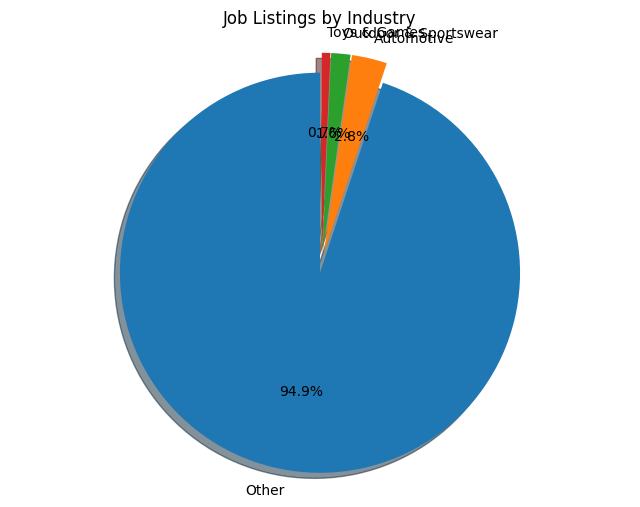

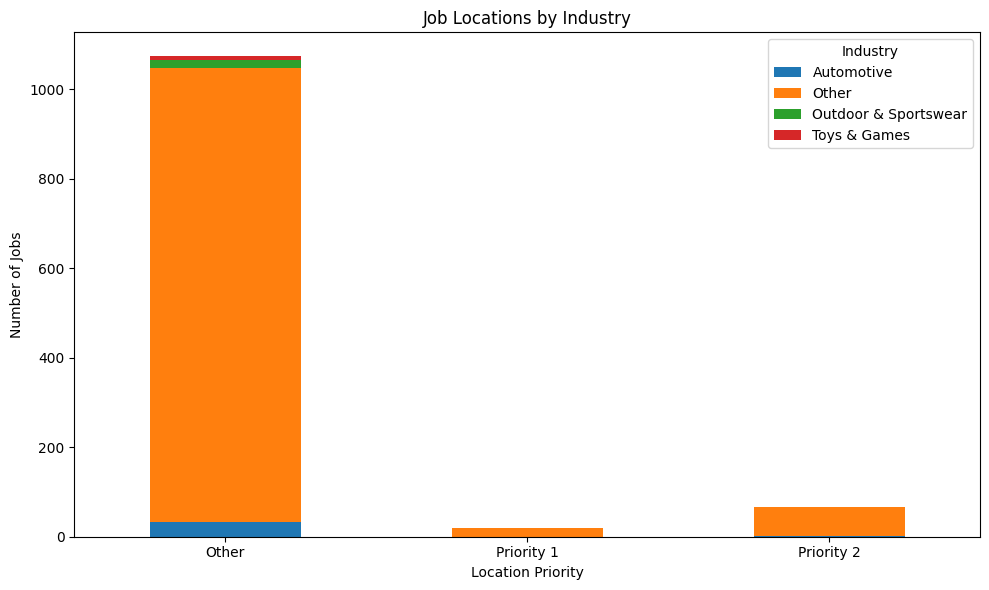


✅ Job scraping complete! Results are displayed above and have been exported to job_results.csv.


In [6]:
run_job_scraper()